Original Shape: (1048575, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,01-12-2009 07:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,01-12-2009 07:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,01-12-2009 07:45,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,01-12-2009 07:45,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,01-12-2009 07:45,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,01-12-2009 07:45,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,01-12-2009 07:46,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,01-12-2009 07:46,3.75,13085.0,United Kingdom


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1048575 non-null  object 
 1   StockCode    1048575 non-null  object 
 2   Description  1044203 non-null  object 
 3   Quantity     1048575 non-null  int64  
 4   InvoiceDate  1048575 non-null  object 
 5   Price        1048575 non-null  float64
 6   Customer ID  811893 non-null   float64
 7   Country      1048575 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 64.0+ MB

Top 10 Countries:
Country
United Kingdom    963819
EIRE               17581
Germany            17327
France             14100
Netherlands         5054
Spain               3740
Switzerland         3189
Belgium             3056
Portugal            2566
Australia           1913
Name: count, dtype: int64

Rows Remaining: 714245
Unique Customers: 5337
Final Shape: (714245, 9)


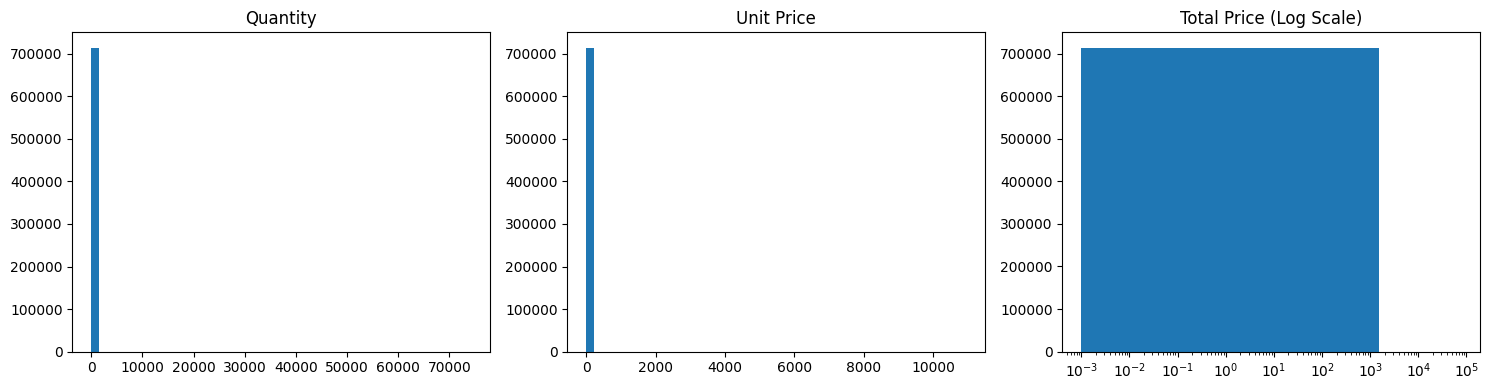


Transactions per Month:
InvoiceDate
2009-12    1429
2010-01     906
2010-02    1001
2010-03    1396
2010-04    1222
2010-05    1270
2010-06    1377
2010-07    1272
2010-08    1193
2010-09    1515
2010-10    1941
2010-11    2373
2010-12    1291
2011-01     874
2011-02     896
2011-03    1177
2011-04    1058
2011-05    1403
2011-06    1249
2011-07    1200
2011-08    1133
2011-09    1568
2011-10    1705
2011-11    2386
2011-12     250
Freq: M, Name: Invoice, dtype: int64

Highest Transaction Month: 2011-11

Top 10 Customers by Total Spend:
Customer ID
18102.0    597336.11
17450.0    246973.09
13694.0    193351.65
17511.0    168224.23
16684.0    141740.79
15061.0    133922.66
16029.0    122209.14
17949.0    116684.08
15311.0    115847.20
13089.0    112670.58
Name: TotalPrice, dtype: float64

Top 10 Highest-Frequency Buyers:
Customer ID
12748.0    331
17841.0    209
15311.0    206
13089.0    201
14606.0    190
17850.0    155
18102.0    142
13694.0    140
15061.0    126
14527.0    121
Name:

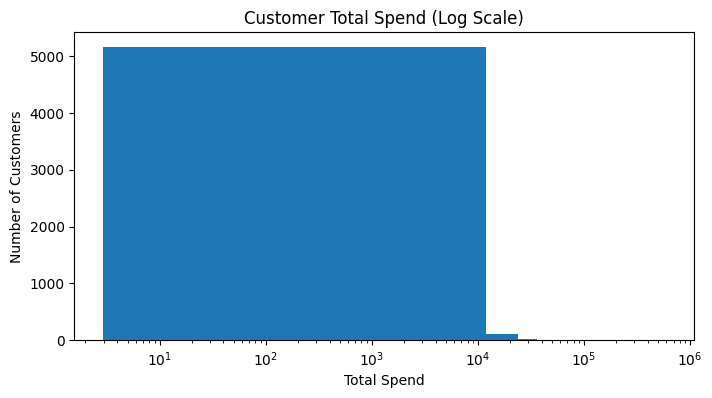


Total Revenue: £ 14343276.62
Customers generating ~80% revenue: 1314
Percentage of customers: 24.62 %


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1.1 LOAD & FILTER THE DATASET
# =========================================================

df = pd.read_csv("online_retail_.csv", encoding="ISO-8859-1")

print("Original Shape:", df.shape)
display(df.head(10))
df.info()

# Top 10 countries BEFORE UK filtering
print("\nTop 10 Countries:")
print(df["Country"].value_counts().head(10))

# Keep UK customers only
df = df[df["Country"] == "United Kingdom"].copy()

# Drop missing CustomerID
df = df.dropna(subset=["Customer ID"])

# Remove returns/cancellations
df = df[df["Quantity"] > 0]

# Remove invalid prices
df = df[df["Price"] > 0]

# Create TotalPrice
df["TotalPrice"] = df["Quantity"] * df["Price"]

# FIXED: Convert InvoiceDate
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

print("\nRows Remaining:", len(df))
print("Unique Customers:", df["Customer ID"].nunique())
print("Final Shape:", df.shape)


# =========================================================
# 1.2 UNIVARIATE ANALYSIS
# =========================================================

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].hist(df["Quantity"], bins=50)
ax[0].set_title("Quantity")

ax[1].hist(df["Price"], bins=50)
ax[1].set_title("Unit Price")

ax[2].hist(df["TotalPrice"], bins=50)
ax[2].set_xscale("log")
ax[2].set_title("Total Price (Log Scale)")

plt.tight_layout()
plt.show()

# Transactions per month
monthly = df.groupby(
    df["InvoiceDate"].dt.to_period("M")
)["Invoice"].nunique()

print("\nTransactions per Month:")
print(monthly)

print("\nHighest Transaction Month:", monthly.idxmax())


# =========================================================
# 1.3 CUSTOMER-LEVEL ANALYSIS
# =========================================================

# Total spend per customer
customer_spend = (
    df.groupby("Customer ID")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

# Order count per customer
customer_orders = (
    df.groupby("Customer ID")["Invoice"]
    .nunique()
    .sort_values(ascending=False)
)

print("\nTop 10 Customers by Total Spend:")
print(customer_spend.head(10))

print("\nTop 10 Highest-Frequency Buyers:")
print(customer_orders.head(10))

print("\nUnique Customers:", df["Customer ID"].nunique())

# Customer spend histogram
plt.figure(figsize=(8, 4))
plt.hist(customer_spend, bins=50)
plt.xscale("log")
plt.xlabel("Total Spend")
plt.ylabel("Number of Customers")
plt.title("Customer Total Spend (Log Scale)")
plt.show()


# 80/20 Pareto Analysis
cumulative = customer_spend.cumsum() / customer_spend.sum() * 100

customers_80 = (cumulative <= 80).sum() + 1
percentage_80 = customers_80 / len(customer_spend) * 100

print("\nTotal Revenue: £", round(df["TotalPrice"].sum(), 2))
print("Customers generating ~80% revenue:", customers_80)
print("Percentage of customers:", round(percentage_80, 2), "%")

RFM Table:


,Customer ID,Recency,Frequency,Monetary
0,12346.0,346,12,77556.46
1,12608.0,425,1,415.79
2,12745.0,507,2,723.85
3,12746.0,561,1,254.55
4,12747.0,43,25,8838.04



RFM Description:


,Recency,Frequency,Monetary
count,5337.000000,5337.000000,5337.000000
mean,228.065955,6.199176,2687.516698
std,208.128404,11.861388,11673.336908
min,26.000000,1.000000,2.900000
25%,51.000000,1.000000,331.350000
50%,128.000000,3.000000,842.410000
75%,403.000000,7.000000,2175.880000
max,759.000000,331.000000,597336.110000


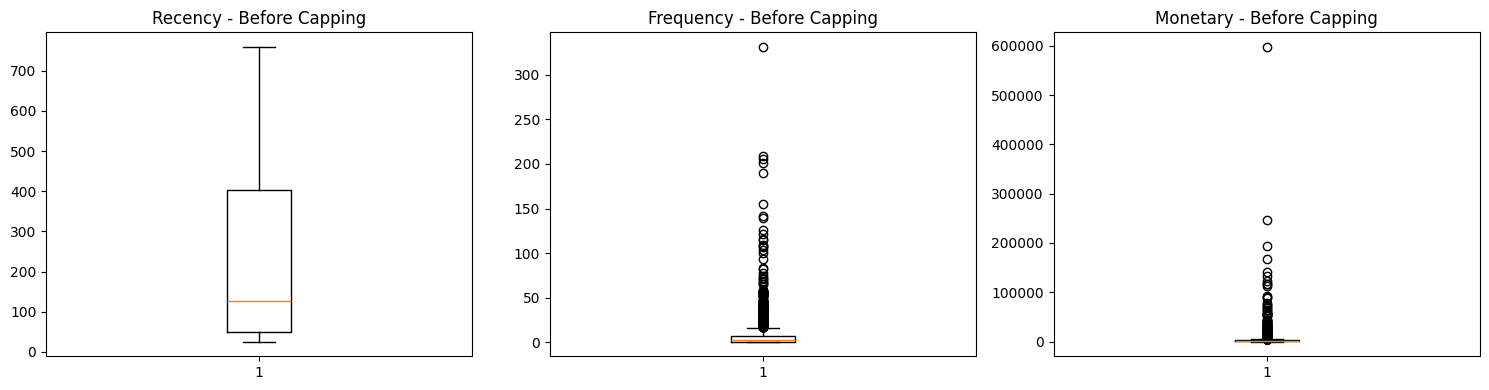

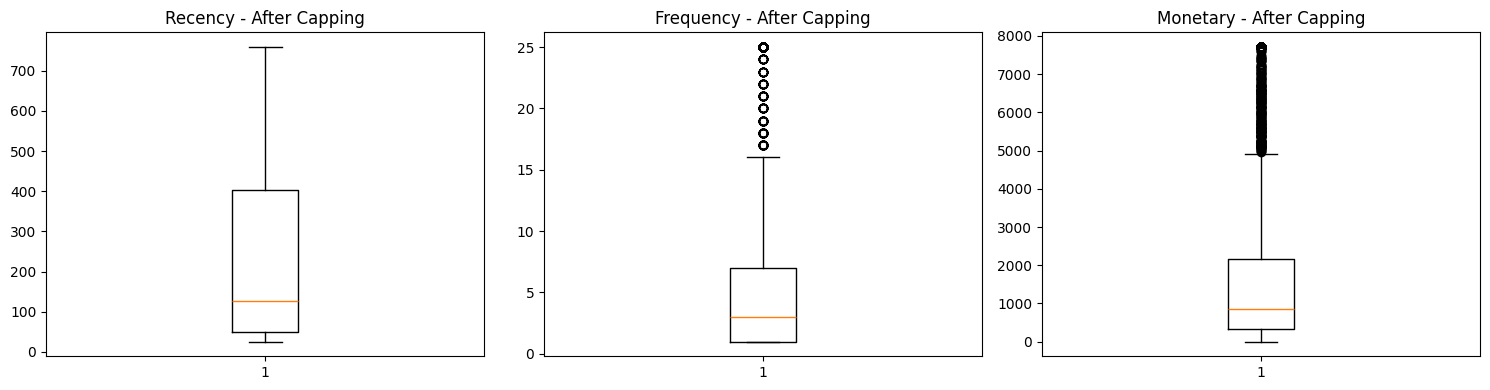

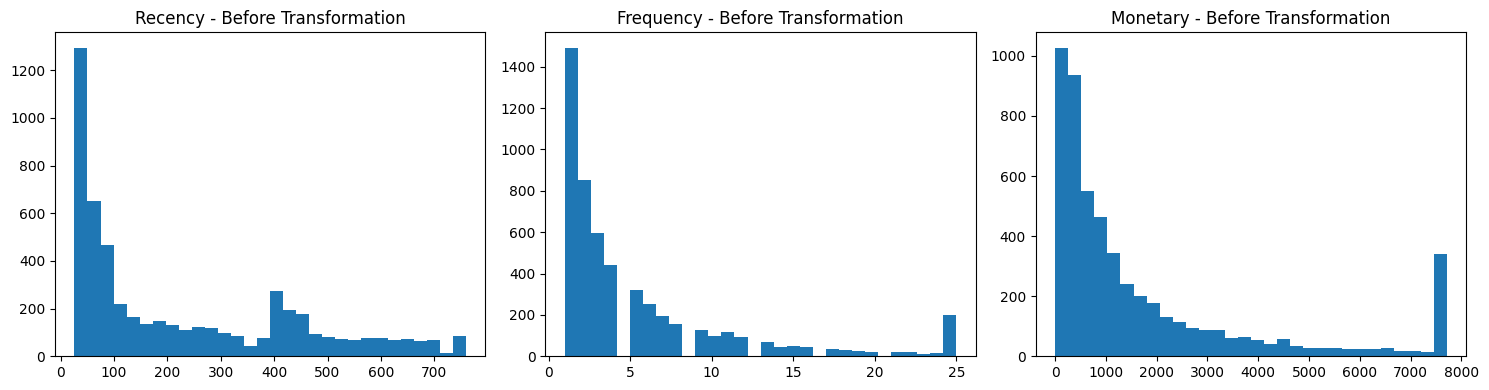

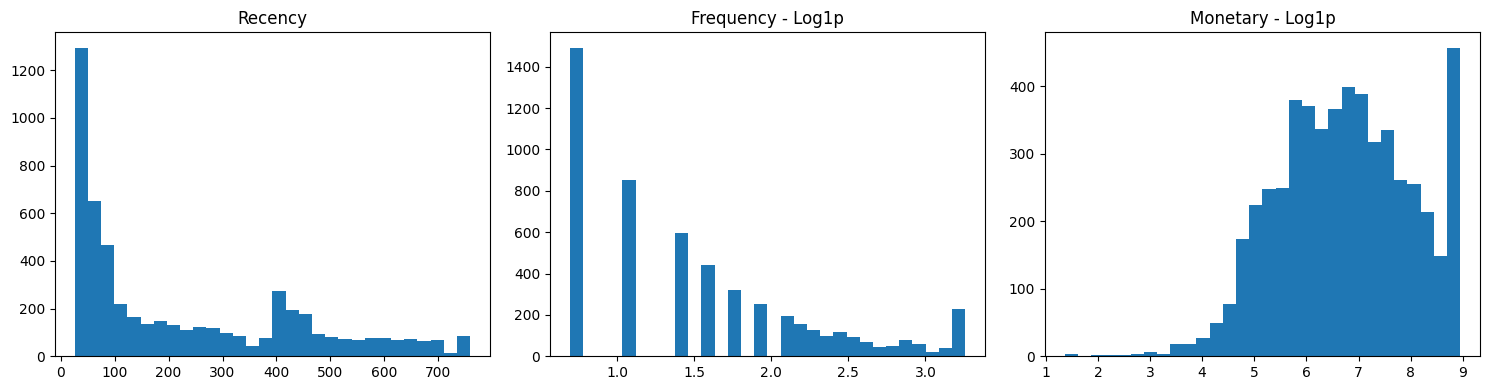


Scaled RFM Data:


,Customer ID,Recency,Frequency_log,Monetary_log
0,12346.0,0.566694,1.363546,1.722668
1,12608.0,0.946303,-1.100608,-0.553512
2,12745.0,1.340327,-0.566829,-0.121811
3,12746.0,1.599807,-1.100608,-0.935116
4,12747.0,-0.889275,2.276046,1.722668



Mean of scaled features:
Recency         -7.655276e-18
Frequency_log    2.043626e-16
Monetary_log     4.979258e-16
dtype: float64

Standard Deviation of scaled features:
Recency          1.000094
Frequency_log    1.000094
Monetary_log     1.000094
dtype: float64

Final RFM Shape: (5337, 4)


,Customer ID,Recency,Frequency_log,Monetary_log
count,5337.000000,5.337000e+03,5.337000e+03,5.337000e+03
mean,15557.010493,-7.655276e-18,2.043626e-16,4.979258e-16
std,1581.111514,1.000094e+00,1.000094e+00,1.000094e+00
min,12346.000000,-9.709626e-01,-1.100608e+00,-4.197898e+00
25%,14191.000000,-8.508331e-01,-1.100608e+00,-7.301250e-01
50%,15566.000000,-4.808346e-01,-1.881069e-01,-3.632306e-03
75%,16923.000000,8.405889e-01,7.243939e-01,7.360679e-01
max,18287.000000,2.551232e+00,2.276046e+00,1.722668e+00


In [15]:
# =========================================================
# STEP 2: RFM FEATURE ENGINEERING & PREPROCESSING
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# =========================================================
# 2.1 BUILD THE RFM TABLE
# =========================================================

# Reference date
reference_date = pd.Timestamp("2011-12-31")

rfm_df = df.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("TotalPrice", "sum")
).reset_index()

print("RFM Table:")
display(rfm_df.head())

print("\nRFM Description:")
display(rfm_df[["Recency", "Frequency", "Monetary"]].describe())


# =========================================================
# 2.2 HANDLE OUTLIERS - IQR METHOD
# =========================================================

# Boxplots BEFORE capping
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(["Recency", "Frequency", "Monetary"]):
    ax[i].boxplot(rfm_df[col])
    ax[i].set_title(f"{col} - Before Capping")

plt.tight_layout()
plt.show()


# Cap values above Q3 + 3*IQR
for col in ["Recency", "Frequency", "Monetary"]:
    Q1 = rfm_df[col].quantile(0.25)
    Q3 = rfm_df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 3 * IQR
    
    rfm_df[col] = rfm_df[col].clip(upper=upper)


# Boxplots AFTER capping
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(["Recency", "Frequency", "Monetary"]):
    ax[i].boxplot(rfm_df[col])
    ax[i].set_title(f"{col} - After Capping")

plt.tight_layout()
plt.show()


# =========================================================
# 2.3 TRANSFORM SKEWED FEATURES
# =========================================================

# Histograms BEFORE transformation
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(["Recency", "Frequency", "Monetary"]):
    ax[i].hist(rfm_df[col], bins=30)
    ax[i].set_title(f"{col} - Before Transformation")

plt.tight_layout()
plt.show()


# Log1p transformation for Frequency and Monetary
rfm_df["Frequency_log"] = np.log1p(rfm_df["Frequency"])
rfm_df["Monetary_log"] = np.log1p(rfm_df["Monetary"])


# Histograms AFTER transformation
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].hist(rfm_df["Recency"], bins=30)
ax[0].set_title("Recency")

ax[1].hist(rfm_df["Frequency_log"], bins=30)
ax[1].set_title("Frequency - Log1p")

ax[2].hist(rfm_df["Monetary_log"], bins=30)
ax[2].set_title("Monetary - Log1p")

plt.tight_layout()
plt.show()


# =========================================================
# 2.4 SCALE THE RFM FEATURES
# =========================================================

features = ["Recency", "Frequency_log", "Monetary_log"]

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_df[features])

# Store as DataFrame
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=features,
    index=rfm_df["Customer ID"]
).reset_index()

print("\nScaled RFM Data:")
display(rfm_scaled.head())


# Check mean and standard deviation
print("\nMean of scaled features:")
print(rfm_scaled[features].mean())

print("\nStandard Deviation of scaled features:")
print(rfm_scaled[features].std())


# =========================================================
# FINAL RFM DATA
# =========================================================

print("\nFinal RFM Shape:", rfm_scaled.shape)
display(rfm_scaled.describe())

Silhouette Scores:
k=2  →  0.4322
k=3  →  0.4081
k=4  →  0.3737
k=5  →  0.3832
k=6  →  0.3522
k=7  →  0.3440
k=8  →  0.3445
k=9  →  0.3187
k=10  →  0.3167

Optimal K: 2


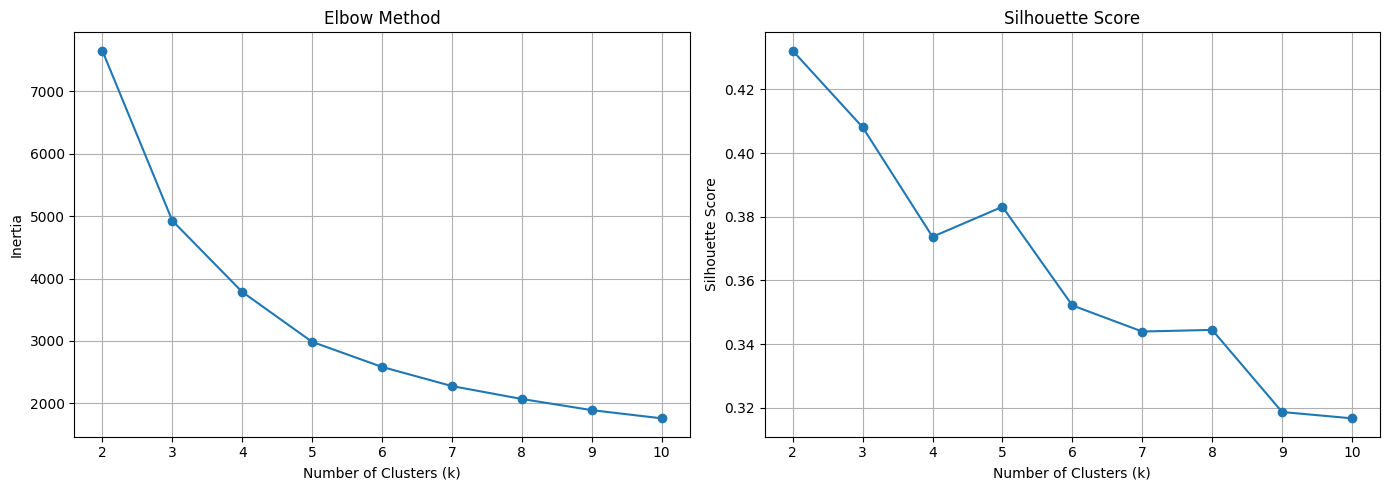


Justification: k=2 has the highest silhouette score, indicating good cluster separation. The elbow curve is also considered before finalising the number of clusters.

Cluster Assignment:


,Customer ID,Recency,Frequency,Monetary,Frequency_log,Monetary_log,KMeans_Cluster
0,12346.0,346,12,7709.47,2.564949,8.950334,1
1,12608.0,425,1,415.79,0.693147,6.032582,0
2,12745.0,507,2,723.85,1.098612,6.585965,0
3,12746.0,561,1,254.55,0.693147,5.543418,0
4,12747.0,43,25,7709.47,3.258097,8.950334,1


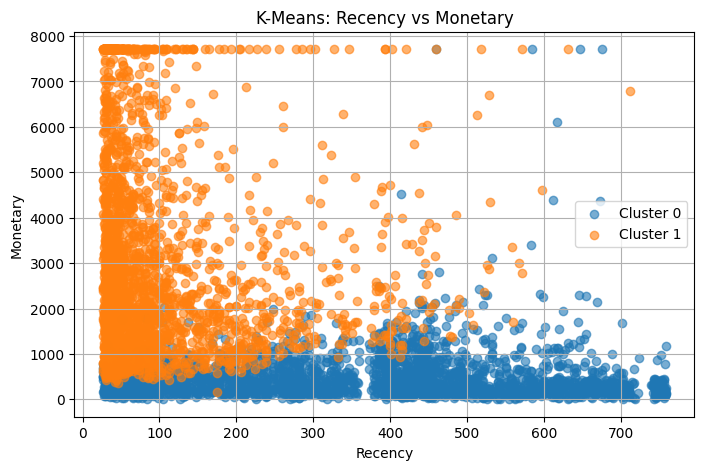

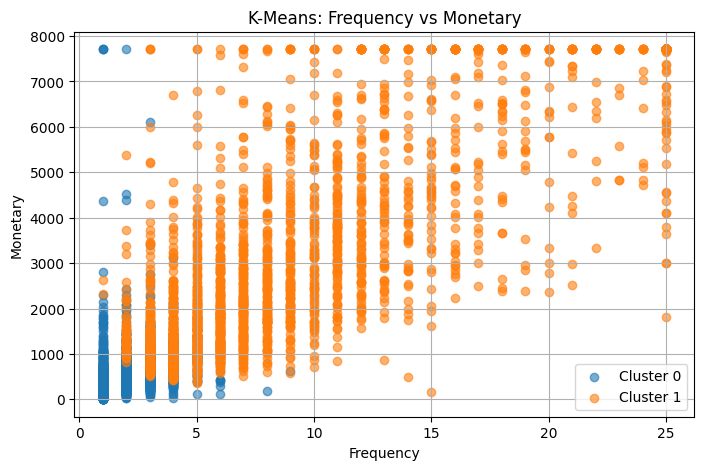

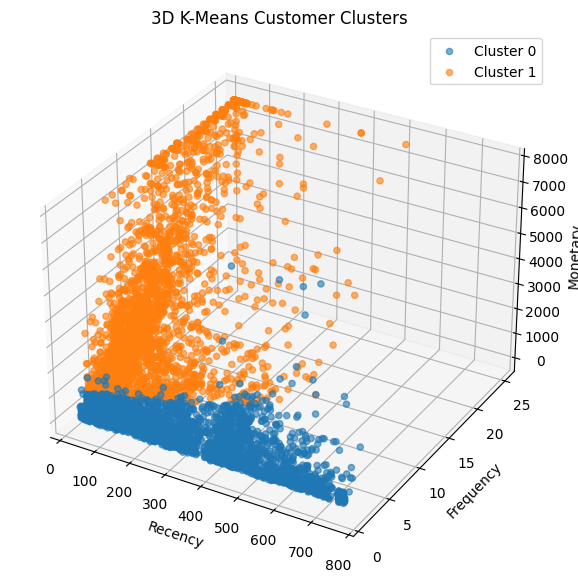

Cluster Profile:


,Recency,Frequency,Monetary,Customers
KMeans_Cluster,,,,
1,97.60,9.42,3186.24,2506
0,343.55,1.78,473.91,2831



Final Customer Segment Profile:


,Recency,Frequency,Monetary,Customers,Persona
KMeans_Cluster,,,,,
1,97.60,9.42,3186.24,2506,Champions
0,343.55,1.78,473.91,2831,At-Risk Customers


In [17]:
# =========================================================
# STEP 3: K-MEANS CLUSTERING
# =========================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Features for clustering
features = ["Recency", "Frequency_log", "Monetary_log"]

# =========================================================
# 3.1 ELBOW METHOD — FIND OPTIMAL K
# =========================================================

k_values = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=42
    )
    
    labels = model.fit_predict(rfm_scaled[features])
    
    inertias.append(model.inertia_)
    silhouette_scores.append(
        silhouette_score(rfm_scaled[features], labels)
    )

# Best K based on highest Silhouette Score
k_optimal = list(k_values)[np.argmax(silhouette_scores)]

print("Silhouette Scores:")
for k, score in zip(k_values, silhouette_scores):
    print(f"k={k}  →  {score:.4f}")

print("\nOptimal K:", k_optimal)


# Elbow + Silhouette plots
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(k_values, inertias, marker="o")
ax[0].set_title("Elbow Method")
ax[0].set_xlabel("Number of Clusters (k)")
ax[0].set_ylabel("Inertia")
ax[0].grid(True)

ax[1].plot(k_values, silhouette_scores, marker="o")
ax[1].set_title("Silhouette Score")
ax[1].set_xlabel("Number of Clusters (k)")
ax[1].set_ylabel("Silhouette Score")
ax[1].grid(True)

plt.tight_layout()
plt.show()

print(
    f"\nJustification: k={k_optimal} has the highest silhouette score, "
    "indicating good cluster separation. The elbow curve is also "
    "considered before finalising the number of clusters."
)


# =========================================================
# 3.2 TRAIN FINAL K-MEANS MODEL
# =========================================================

kmeans = KMeans(
    n_clusters=k_optimal,
    init="k-means++",
    n_init=20,
    max_iter=500,
    random_state=42
)

rfm_scaled["KMeans_Cluster"] = kmeans.fit_predict(
    rfm_scaled[features]
)

# Add cluster labels to ORIGINAL unscaled RFM data
rfm_df["KMeans_Cluster"] = rfm_scaled["KMeans_Cluster"].values

print("\nCluster Assignment:")
display(rfm_df.head())


# =========================================================
# 3.3 VISUALISE K-MEANS CLUSTERS
# =========================================================

# 2D: Recency vs Monetary
plt.figure(figsize=(8, 5))

for cluster in sorted(rfm_df["KMeans_Cluster"].unique()):
    data = rfm_df[rfm_df["KMeans_Cluster"] == cluster]
    plt.scatter(
        data["Recency"],
        data["Monetary"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.title("K-Means: Recency vs Monetary")
plt.legend()
plt.grid(True)
plt.show()


# 2D: Frequency vs Monetary
plt.figure(figsize=(8, 5))

for cluster in sorted(rfm_df["KMeans_Cluster"].unique()):
    data = rfm_df[rfm_df["KMeans_Cluster"] == cluster]
    plt.scatter(
        data["Frequency"],
        data["Monetary"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("K-Means: Frequency vs Monetary")
plt.legend()
plt.grid(True)
plt.show()


# 3D: Recency vs Frequency vs Monetary
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

for cluster in sorted(rfm_df["KMeans_Cluster"].unique()):
    data = rfm_df[rfm_df["KMeans_Cluster"] == cluster]
    
    ax.scatter(
        data["Recency"],
        data["Frequency"],
        data["Monetary"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")
ax.set_title("3D K-Means Customer Clusters")
ax.legend()

plt.show()


# =========================================================
# 3.4 PROFILE THE K-MEANS CLUSTERS
# =========================================================

cluster_profile = (
    rfm_df.groupby("KMeans_Cluster")
    .agg(
        Recency=("Recency", "mean"),
        Frequency=("Frequency", "mean"),
        Monetary=("Monetary", "mean")
    )
)

# Number of customers in each cluster
cluster_profile["Customers"] = rfm_df.groupby(
    "KMeans_Cluster"
).size()

# Sort by Monetary descending
cluster_profile = cluster_profile.sort_values(
    "Monetary",
    ascending=False
)

print("Cluster Profile:")
display(cluster_profile.round(2))


# ---------------------------------------------------------
# Business Personas
# ---------------------------------------------------------

median_r = cluster_profile["Recency"].median()
median_f = cluster_profile["Frequency"].median()
median_m = cluster_profile["Monetary"].median()


def persona(row):
    
    # Low Recency = recent customer
    # High Frequency + High Monetary = valuable customer
    
    if (
        row["Recency"] <= median_r
        and row["Frequency"] >= median_f
        and row["Monetary"] >= median_m
    ):
        return "Champions"
    
    elif row["Recency"] > median_r:
        return "At-Risk Customers"
    
    elif row["Monetary"] >= median_m:
        return "High-Value Customers"
    
    else:
        return "New Customers"


cluster_profile["Persona"] = cluster_profile.apply(
    persona,
    axis=1
)

print("\nFinal Customer Segment Profile:")
display(cluster_profile.round(2))

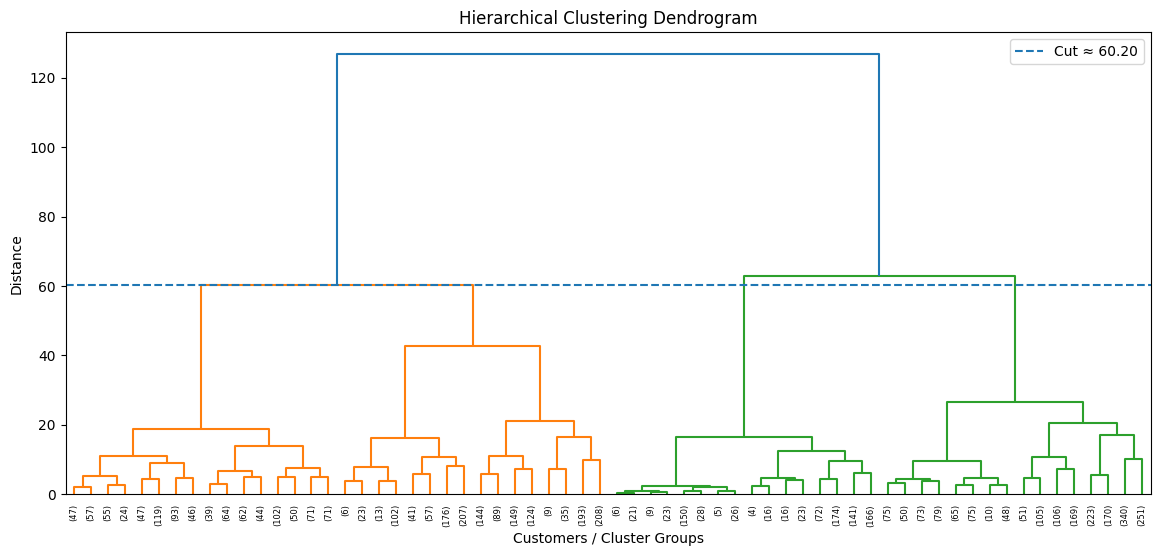

Chosen number of clusters: 4
Approximate cut distance: 60.2

Silhouette Score Comparison:


,Silhouette Score
ward,0.3441
complete,0.3239
average,0.3043


Best Linkage: ward
Highest Silhouette Score: 0.3441


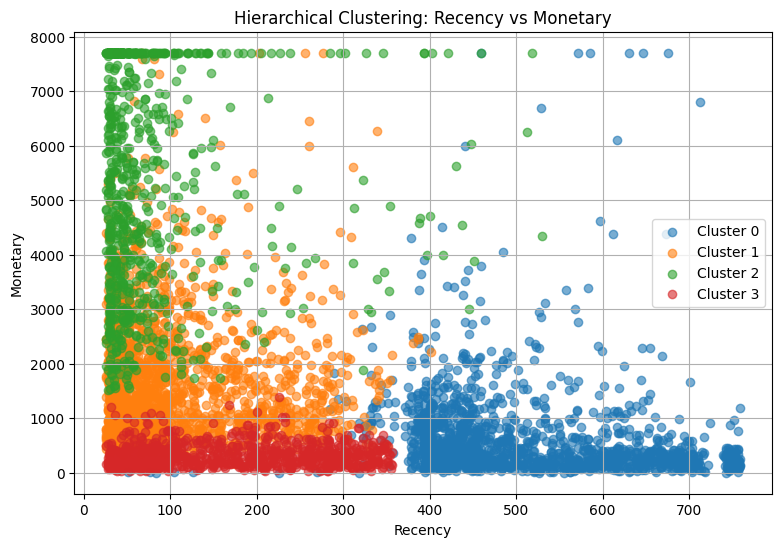

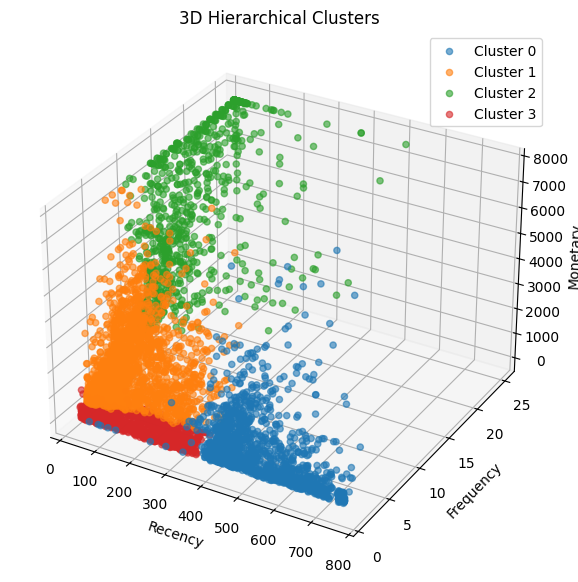


Hierarchical Cluster Profile:


,Recency,Frequency,Monetary,Customers
Agg_Cluster,,,,
2,70.59,16.76,5569.29,880
1,101.14,4.88,1650.15,1890
0,511.73,2.05,626.04,1576
3,158.85,1.45,322.87,991



Hierarchical Cluster Personas:


,Recency,Frequency,Monetary,Customers,Persona
Agg_Cluster,,,,,
2,70.59,16.76,5569.29,880,Champions
1,101.14,4.88,1650.15,1890,Champions
0,511.73,2.05,626.04,1576,At-Risk Customers
3,158.85,1.45,322.87,991,At-Risk Customers



K-Means vs Hierarchical Cluster Comparison:


Agg_Cluster,0,1,2,3
KMeans_Cluster,,,,
0,1484,356,0,991
1,92,1534,880,0



Comparison:
The two clustering methods may not assign exactly the same
cluster numbers because cluster labels are arbitrary. 
The important comparison is whether customers with similar
RFM characteristics are grouped together.



In [18]:
# =========================================================
# STEP 4: AGGLOMERATIVE HIERARCHICAL CLUSTERING
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score


# Features used for clustering
features = ["Recency", "Frequency_log", "Monetary_log"]
X = rfm_scaled[features]


# =========================================================
# 4.1 DENDROGRAM ANALYSIS
# =========================================================

# Ward linkage
Z = linkage(X, method="ward")

plt.figure(figsize=(14, 6))

dendrogram(
    Z,
    truncate_mode="level",
    p=5,
    leaf_rotation=90
)

# Choose number of clusters
n_chosen = 4

# Approximate cut line
cut_distance = Z[-(n_chosen - 1), 2]

plt.axhline(
    y=cut_distance,
    linestyle="--",
    label=f"Cut ≈ {cut_distance:.2f}"
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers / Cluster Groups")
plt.ylabel("Distance")
plt.legend()
plt.show()

print("Chosen number of clusters:", n_chosen)
print("Approximate cut distance:", round(cut_distance, 2))


# =========================================================
# 4.2 TRAIN AGGLOMERATIVE MODELS
# =========================================================

linkage_results = {}

for method in ["ward", "complete", "average"]:

    model = AgglomerativeClustering(
        n_clusters=n_chosen,
        linkage=method
    )

    labels = model.fit_predict(X)

    score = silhouette_score(X, labels)

    linkage_results[method] = {
        "Model": model,
        "Labels": labels,
        "Silhouette": score
    }

# Compare silhouette scores
comparison = pd.DataFrame({
    method: [result["Silhouette"]]
    for method, result in linkage_results.items()
}, index=["Silhouette Score"]).T

print("\nSilhouette Score Comparison:")
display(comparison.round(4))

# Select best linkage
best_linkage = comparison["Silhouette Score"].idxmax()

print("Best Linkage:", best_linkage)
print(
    "Highest Silhouette Score:",
    round(comparison.loc[best_linkage, "Silhouette Score"], 4)
)

# Final labels
rfm_df["Agg_Cluster"] = linkage_results[best_linkage]["Labels"]


# =========================================================
# 4.3 VISUALISE & PROFILE HIERARCHICAL CLUSTERS
# =========================================================

# ---------- 2D Scatter ----------
plt.figure(figsize=(9, 6))

for cluster in sorted(rfm_df["Agg_Cluster"].unique()):

    data = rfm_df[rfm_df["Agg_Cluster"] == cluster]

    plt.scatter(
        data["Recency"],
        data["Monetary"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.title("Hierarchical Clustering: Recency vs Monetary")
plt.legend()
plt.grid(True)
plt.show()


# ---------- 3D Scatter ----------
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

for cluster in sorted(rfm_df["Agg_Cluster"].unique()):

    data = rfm_df[rfm_df["Agg_Cluster"] == cluster]

    ax.scatter(
        data["Recency"],
        data["Frequency"],
        data["Monetary"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")
ax.set_title("3D Hierarchical Clusters")
ax.legend()

plt.show()


# ---------- Cluster Profile ----------
agg_profile = (
    rfm_df.groupby("Agg_Cluster")
    .agg(
        Recency=("Recency", "mean"),
        Frequency=("Frequency", "mean"),
        Monetary=("Monetary", "mean")
    )
)

agg_profile["Customers"] = (
    rfm_df.groupby("Agg_Cluster").size()
)

agg_profile = agg_profile.sort_values(
    "Monetary",
    ascending=False
)

print("\nHierarchical Cluster Profile:")
display(agg_profile.round(2))


# =========================================================
# BUSINESS PERSONAS
# =========================================================

median_r = agg_profile["Recency"].median()
median_f = agg_profile["Frequency"].median()
median_m = agg_profile["Monetary"].median()


def assign_persona(row):

    if (
        row["Recency"] <= median_r
        and row["Frequency"] >= median_f
        and row["Monetary"] >= median_m
    ):
        return "Champions"

    elif row["Recency"] > median_r:
        return "At-Risk Customers"

    elif row["Monetary"] >= median_m:
        return "High-Value Customers"

    else:
        return "New Customers"


agg_profile["Persona"] = agg_profile.apply(
    assign_persona,
    axis=1
)

print("\nHierarchical Cluster Personas:")
display(agg_profile.round(2))


# =========================================================
# COMPARE K-MEANS VS HIERARCHICAL
# =========================================================

comparison_table = pd.crosstab(
    rfm_df["KMeans_Cluster"],
    rfm_df["Agg_Cluster"]
)

print("\nK-Means vs Hierarchical Cluster Comparison:")
display(comparison_table)

print("""
Comparison:
The two clustering methods may not assign exactly the same
cluster numbers because cluster labels are arbitrary. 
The important comparison is whether customers with similar
RFM characteristics are grouped together.
""")


========== 5.1 EPSILON TUNING ==========


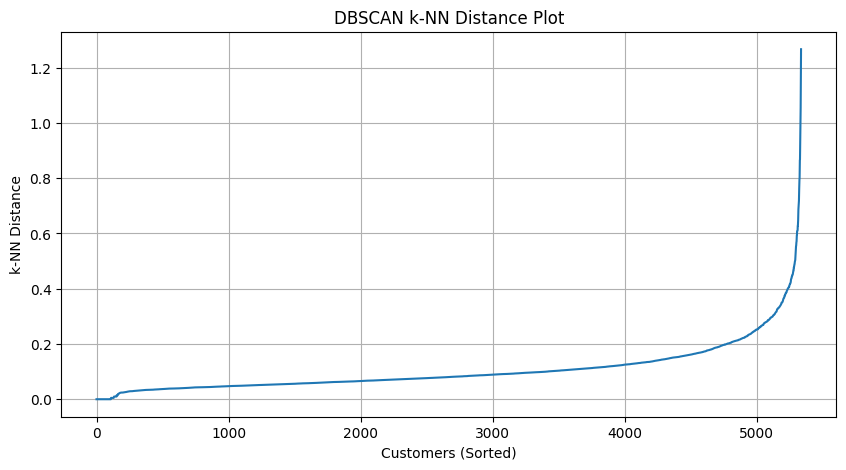

Optimal Epsilon (eps): 0.2044

========== 5.2 TRAIN DBSCAN ==========
Number of Clusters: 11
Number of Noise Points: 344
Noise Percentage: 6.45 %

========== 5.3 HYPERPARAMETER TUNING ==========

Hyperparameter Results:


,eps,min_samples,Silhouette Score
0,0.3,3,0.0014
1,0.3,5,0.1023
2,0.3,8,0.1962
3,0.3,10,0.1983
4,0.5,3,0.3011
5,0.5,5,0.3306
6,0.5,8,0.3305
7,0.5,10,0.3305
8,0.7,3,NaN
9,0.7,5,NaN


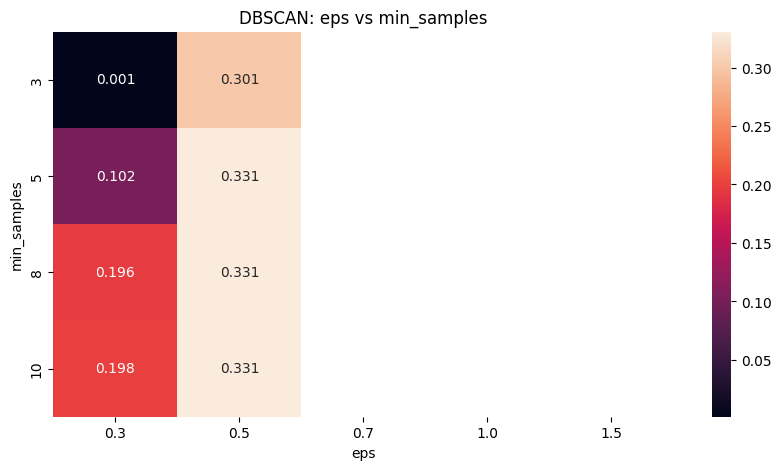


Best Parameters:
Best eps: 0.5
Best min_samples: 5

========== 5.4 VISUALISE & PROFILE ==========


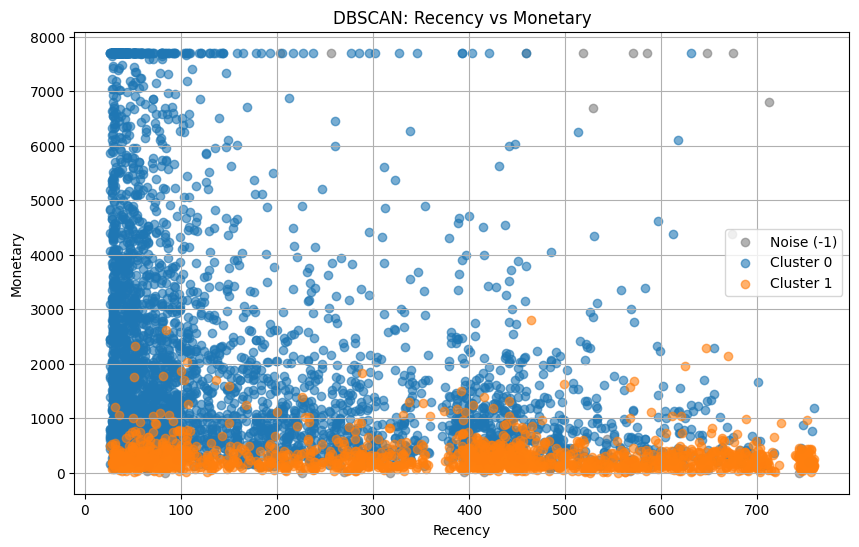

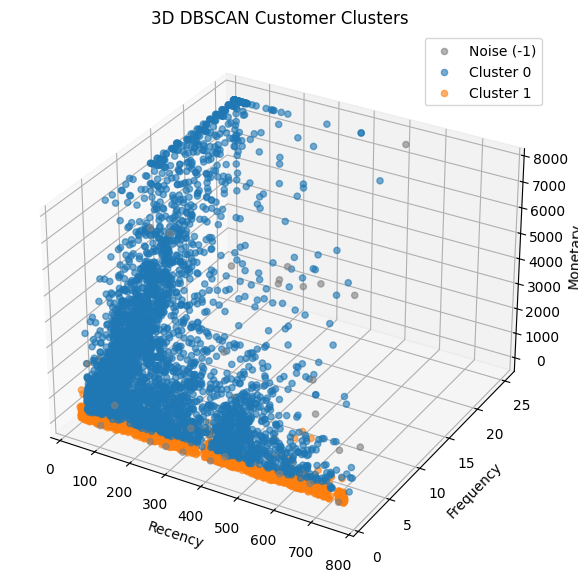


DBSCAN Cluster Profile:


,Recency,Frequency,Monetary,Customers
DBSCAN_Cluster,,,,
0,168.99,7.07,2298.27,3829
1,376.66,1.00,300.31,1482



Business Personas:


,Recency,Frequency,Monetary,Customers,Persona
DBSCAN_Cluster,,,,,
0,168.99,7.07,2298.27,3829,Champions
1,376.66,1.00,300.31,1482,At-Risk Customers



FINAL DBSCAN SUMMARY
Best eps: 0.5
Best min_samples: 5
Number of Clusters: 3
Noise Points: 26
Noise Percentage: 0.49 %

Interpretation: DBSCAN identifies dense customer groups and marks unusual RFM patterns as noise (-1).


In [21]:
# =========================================================
# STEP 5: DBSCAN CLUSTERING
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score


# Scaled RFM features from Step 2
features = ["Recency", "Frequency_log", "Monetary_log"]
X = rfm_scaled[features]


# =========================================================
# 5.1 TUNE EPSILON (ε) USING k-NN DISTANCE PLOT
# =========================================================

print("\n========== 5.1 EPSILON TUNING ==========")

# MinPts = 5
MinPts = 5

# k = MinPts - 1
k = MinPts - 1

# Nearest Neighbours
knn = NearestNeighbors(n_neighbors=MinPts)
knn.fit(X)

distances, indices = knn.kneighbors(X)

# k-nearest neighbour distances
k_distances = np.sort(distances[:, k])

# Plot
plt.figure(figsize=(10, 5))
plt.plot(k_distances)

plt.xlabel("Customers (Sorted)")
plt.ylabel("k-NN Distance")
plt.title("DBSCAN k-NN Distance Plot")

plt.grid(True)
plt.show()


# Select epsilon
# 90th percentile gives a valid positive epsilon
optimal_eps = float(np.percentile(k_distances, 90))

# Safety check
if optimal_eps <= 0:
    optimal_eps = 0.5

print("Optimal Epsilon (eps):", round(optimal_eps, 4))


# =========================================================
# 5.2 TRAIN DBSCAN MODEL
# =========================================================

print("\n========== 5.2 TRAIN DBSCAN ==========")

dbscan = DBSCAN(
    eps=optimal_eps,
    min_samples=5,
    metric="euclidean"
)

labels = dbscan.fit_predict(X)

# Add cluster labels to RFM dataframe
rfm_df["DBSCAN_Cluster"] = labels

# Number of clusters excluding noise (-1)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

# Number of noise points
noise_points = np.sum(labels == -1)

# Percentage of noise
noise_percent = (noise_points / len(labels)) * 100

print("Number of Clusters:", n_clusters)
print("Number of Noise Points:", noise_points)
print("Noise Percentage:", round(noise_percent, 2), "%")


# =========================================================
# 5.3 TUNE DBSCAN HYPERPARAMETERS
# =========================================================

print("\n========== 5.3 HYPERPARAMETER TUNING ==========")

# Given values from question
eps_values = [0.3, 0.5, 0.7, 1.0, 1.5]
min_samples_values = [3, 5, 8, 10]

results = []

for eps in eps_values:

    for min_samples in min_samples_values:

        model = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            metric="euclidean"
        )

        temp_labels = model.fit_predict(X)

        # Exclude noise for silhouette score
        mask = temp_labels != -1

        cluster_labels = temp_labels[mask]

        # Need at least 2 clusters
        if len(set(cluster_labels)) >= 2:

            score = silhouette_score(
                X[mask],
                cluster_labels
            )

        else:
            score = np.nan

        results.append({
            "eps": eps,
            "min_samples": min_samples,
            "Silhouette Score": score
        })


# Results DataFrame
results_df = pd.DataFrame(results)

print("\nHyperparameter Results:")
display(results_df.round(4))


# Heatmap
heatmap_data = results_df.pivot(
    index="min_samples",
    columns="eps",
    values="Silhouette Score"
)

plt.figure(figsize=(10, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f"
)

plt.title("DBSCAN: eps vs min_samples")
plt.xlabel("eps")
plt.ylabel("min_samples")

plt.show()


# Select best combination
valid_results = results_df.dropna(
    subset=["Silhouette Score"]
)

if len(valid_results) > 0:

    best_row = valid_results.loc[
        valid_results["Silhouette Score"].idxmax()
    ]

    best_eps = float(best_row["eps"])
    best_min_samples = int(
        best_row["min_samples"]
    )

else:

    best_eps = 0.5
    best_min_samples = 5


print("\nBest Parameters:")
print("Best eps:", best_eps)
print("Best min_samples:", best_min_samples)


# Train final DBSCAN
dbscan_final = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples,
    metric="euclidean"
)

rfm_df["DBSCAN_Cluster"] = (
    dbscan_final.fit_predict(X)
)


# =========================================================
# 5.4 VISUALISE & PROFILE DBSCAN CLUSTERS
# =========================================================

print("\n========== 5.4 VISUALISE & PROFILE ==========")


# ---------------------------------------------------------
# 5.4.1 2D Scatter Plot
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

for cluster in sorted(
    rfm_df["DBSCAN_Cluster"].unique()
):

    data = rfm_df[
        rfm_df["DBSCAN_Cluster"] == cluster
    ]

    if cluster == -1:

        plt.scatter(
            data["Recency"],
            data["Monetary"],
            color="gray",
            label="Noise (-1)",
            alpha=0.6
        )

    else:

        plt.scatter(
            data["Recency"],
            data["Monetary"],
            label=f"Cluster {cluster}",
            alpha=0.6
        )


plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.title("DBSCAN: Recency vs Monetary")
plt.legend()
plt.grid(True)
plt.show()


# ---------------------------------------------------------
# 5.4.2 3D Scatter Plot
# ---------------------------------------------------------

fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(
    111,
    projection="3d"
)

for cluster in sorted(
    rfm_df["DBSCAN_Cluster"].unique()
):

    data = rfm_df[
        rfm_df["DBSCAN_Cluster"] == cluster
    ]

    if cluster == -1:

        ax.scatter(
            data["Recency"],
            data["Frequency"],
            data["Monetary"],
            color="gray",
            label="Noise (-1)",
            alpha=0.6
        )

    else:

        ax.scatter(
            data["Recency"],
            data["Frequency"],
            data["Monetary"],
            label=f"Cluster {cluster}",
            alpha=0.6
        )


ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")

ax.set_title(
    "3D DBSCAN Customer Clusters"
)

ax.legend()

plt.show()


# ---------------------------------------------------------
# 5.4.3 PROFILE DBSCAN CLUSTERS
# ---------------------------------------------------------

# Remove noise
profile_data = rfm_df[
    rfm_df["DBSCAN_Cluster"] != -1
]


if len(profile_data) > 0:

    dbscan_profile = (
        profile_data
        .groupby("DBSCAN_Cluster")
        .agg(
            Recency=("Recency", "mean"),
            Frequency=("Frequency", "mean"),
            Monetary=("Monetary", "mean"),
            Customers=("Recency", "size")
        )
        .sort_values(
            "Monetary",
            ascending=False
        )
    )

    print("\nDBSCAN Cluster Profile:")
    display(
        dbscan_profile.round(2)
    )


    # -----------------------------------------------------
    # 5.4.4 BUSINESS PERSONAS
    # -----------------------------------------------------

    median_r = dbscan_profile[
        "Recency"
    ].median()

    median_f = dbscan_profile[
        "Frequency"
    ].median()

    median_m = dbscan_profile[
        "Monetary"
    ].median()


    def assign_persona(row):

        if (
            row["Recency"] <= median_r
            and
            row["Frequency"] >= median_f
            and
            row["Monetary"] >= median_m
        ):
            return "Champions"

        elif row["Recency"] > median_r:
            return "At-Risk Customers"

        elif row["Monetary"] >= median_m:
            return "High-Value Customers"

        else:
            return "New Customers"


    dbscan_profile["Persona"] = (
        dbscan_profile.apply(
            assign_persona,
            axis=1
        )
    )

    print("\nBusiness Personas:")
    display(
        dbscan_profile.round(2)
    )


# =========================================================
# FINAL DBSCAN SUMMARY
# =========================================================

final_labels = rfm_df["DBSCAN_Cluster"]

final_clusters = (
    len(set(final_labels))
    - (1 if -1 in final_labels else 0)
)

final_noise = np.sum(
    final_labels == -1
)

final_noise_percent = (
    final_noise / len(final_labels)
) * 100


print("\n" + "=" * 55)
print("FINAL DBSCAN SUMMARY")
print("=" * 55)

print("Best eps:", best_eps)
print("Best min_samples:", best_min_samples)
print("Number of Clusters:", final_clusters)
print("Noise Points:", final_noise)
print(
    "Noise Percentage:",
    round(final_noise_percent, 2),
    "%"
)

print(
    "\nInterpretation: DBSCAN identifies dense customer groups "
    "and marks unusual RFM patterns as noise (-1)."
)

In [22]:
# =========================================================
# STEP 6: ALGORITHM COMPARISON & BUSINESS INTERPRETATION
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)


# Scaled RFM features
features = ["Recency", "Frequency_log", "Monetary_log"]
X = rfm_scaled[features]


# =========================================================
# 6.1 INTERNAL METRICS COMPARISON TABLE
# =========================================================

print("\n" + "=" * 60)
print("6.1 INTERNAL METRICS COMPARISON")
print("=" * 60)


# ---------------------------------------------------------
# K-MEANS
# ---------------------------------------------------------

kmeans_labels = rfm_df["KMeans_Cluster"].values

kmeans_clusters = len(np.unique(kmeans_labels))

kmeans_silhouette = silhouette_score(
    X,
    kmeans_labels
)

kmeans_db = davies_bouldin_score(
    X,
    kmeans_labels
)

kmeans_ch = calinski_harabasz_score(
    X,
    kmeans_labels
)


# ---------------------------------------------------------
# AGGLOMERATIVE
# ---------------------------------------------------------

agg_labels = rfm_df["Agg_Cluster"].values

agg_clusters = len(np.unique(agg_labels))

agg_silhouette = silhouette_score(
    X,
    agg_labels
)

agg_db = davies_bouldin_score(
    X,
    agg_labels
)

agg_ch = calinski_harabasz_score(
    X,
    agg_labels
)


# ---------------------------------------------------------
# DBSCAN
# ---------------------------------------------------------

dbscan_labels = rfm_df["DBSCAN_Cluster"].values

# Remove noise (-1)
db_mask = dbscan_labels != -1

db_labels_clean = dbscan_labels[db_mask]
X_db = X.iloc[db_mask]

db_clusters = len(np.unique(db_labels_clean))

# Check whether DBSCAN has at least 2 clusters
if db_clusters >= 2:

    db_silhouette = silhouette_score(
        X_db,
        db_labels_clean
    )

    db_db = davies_bouldin_score(
        X_db,
        db_labels_clean
    )

    db_ch = calinski_harabasz_score(
        X_db,
        db_labels_clean
    )

else:

    db_silhouette = np.nan
    db_db = np.nan
    db_ch = np.nan


db_noise_percent = (
    np.sum(dbscan_labels == -1)
    / len(dbscan_labels)
) * 100


# ---------------------------------------------------------
# FINAL COMPARISON TABLE
# ---------------------------------------------------------

comparison_df = pd.DataFrame({

    "Algorithm": [
        "K-Means",
        "Agglomerative",
        "DBSCAN"
    ],

    "Hyperparameters": [
        f"k={len(np.unique(kmeans_labels))}",
        f"k={len(np.unique(agg_labels))}, linkage={globals().get('best_linkage', 'ward')}",
        f"eps={globals().get('best_eps', 'N/A')}, min_samples={globals().get('best_min_samples', 'N/A')}"
    ],

    "Clusters": [
        kmeans_clusters,
        agg_clusters,
        db_clusters
    ],

    "Silhouette Score": [
        kmeans_silhouette,
        agg_silhouette,
        db_silhouette
    ],

    "Davies-Bouldin": [
        kmeans_db,
        agg_db,
        db_db
    ],

    "Calinski-Harabasz": [
        kmeans_ch,
        agg_ch,
        db_ch
    ],

    "Noise %": [
        0,
        0,
        db_noise_percent
    ]
})


print("\nFinal Comparison Table:")
display(comparison_df.round(4))


# ---------------------------------------------------------
# METRIC RANKING
# ---------------------------------------------------------

# Higher Silhouette = Better
comparison_df["Silhouette_Rank"] = (
    comparison_df["Silhouette Score"]
    .rank(ascending=False)
)

# Lower Davies-Bouldin = Better
comparison_df["DB_Rank"] = (
    comparison_df["Davies-Bouldin"]
    .rank(ascending=True)
)

# Higher Calinski-Harabasz = Better
comparison_df["CH_Rank"] = (
    comparison_df["Calinski-Harabasz"]
    .rank(ascending=False)
)

comparison_df["Total Rank"] = (
    comparison_df["Silhouette_Rank"]
    + comparison_df["DB_Rank"]
    + comparison_df["CH_Rank"]
)

ranking_df = comparison_df.sort_values(
    "Total Rank"
)

print("\nMetric Ranking:")
display(
    ranking_df[
        [
            "Algorithm",
            "Silhouette Score",
            "Davies-Bouldin",
            "Calinski-Harabasz",
            "Total Rank"
        ]
    ].round(4)
)

print("""
Interpretation:
Silhouette Score: Higher is better.
Davies-Bouldin Index: Lower is better.
Calinski-Harabasz Index: Higher is better.
The algorithm with the strongest overall internal metrics
provides the most well-separated and compact clusters.
""")


# =========================================================
# 6.2 K-MEANS CLUSTER STABILITY CHECK
# =========================================================

print("\n" + "=" * 60)
print("6.2 K-MEANS CLUSTER STABILITY CHECK")
print("=" * 60)


# Use same k as final K-Means
k_stability = len(
    np.unique(rfm_df["KMeans_Cluster"])
)

seeds = [0, 7, 21, 42, 99]

stability_results = []

for seed in seeds:

    model = KMeans(
        n_clusters=k_stability,
        init="k-means++",
        n_init=20,
        random_state=seed
    )

    labels = model.fit_predict(X)

    score = silhouette_score(
        X,
        labels
    )

    stability_results.append({
        "Random State": seed,
        "Silhouette Score": score
    })


stability_df = pd.DataFrame(
    stability_results
)

print("\nK-Means Stability Results:")
display(stability_df.round(4))


# Mean and standard deviation
mean_score = stability_df[
    "Silhouette Score"
].mean()

std_score = stability_df[
    "Silhouette Score"
].std()

print("Mean Silhouette Score:", round(mean_score, 4))
print("Standard Deviation:", round(std_score, 4))


# Stability interpretation
if std_score < 0.02:

    print(
        "Conclusion: K-Means is relatively stable across runs."
    )

elif std_score < 0.05:

    print(
        "Conclusion: K-Means shows moderate variation across runs."
    )

else:

    print(
        "Conclusion: K-Means shows noticeable variation across runs."
    )


# =========================================================
# 6.3 BUSINESS RECOMMENDATION
# =========================================================

print("\n" + "=" * 60)
print("6.3 BUSINESS RECOMMENDATION")
print("=" * 60)


# Select algorithm based on total internal metric rank
recommended_algorithm = ranking_df.iloc[0]["Algorithm"]

print(f"""
BUSINESS RECOMMENDATION

Based on the internal clustering metrics, {recommended_algorithm}
produced the strongest overall combination of cluster separation
and compactness among the tested algorithms.

The customer segmentation can be used to create targeted
marketing campaigns instead of treating all customers equally.

Suggested customer actions:

1. Champions
   - Recently purchased, frequent and high-spending customers.
   - Action: Invite them to exclusive loyalty rewards,
     Flipkart Plus membership or early-access offers.

2. High-Value Customers
   - Customers with comparatively high monetary value.
   - Action: Provide premium offers, cross-selling and
     personalized product recommendations.

3. New Customers
   - Customers with lower purchase frequency or spending.
   - Action: Send welcome offers and encourage a second purchase.

4. At-Risk Customers
   - Customers with high recency values, indicating
     they have not purchased recently.
   - Action: Send targeted discount coupons with limited
     validity to encourage reactivation.

Additional data that could improve segmentation:

- Product categories
- Customer age / demographic information
- Average order value
- Purchase frequency by product category
- Discount usage
- Marketing campaign response
- Online browsing behaviour
- Payment method
- Customer acquisition channel
- Return / cancellation behaviour

These additional variables could provide more detailed
customer behaviour information beyond RFM.
""")


# =========================================================
# FINAL SUMMARY TABLE
# =========================================================

print("\n" + "=" * 60)
print("FINAL ALGORITHM SUMMARY")
print("=" * 60)

final_table = comparison_df[
    [
        "Algorithm",
        "Hyperparameters",
        "Clusters",
        "Silhouette Score",
        "Davies-Bouldin",
        "Calinski-Harabasz",
        "Noise %"
    ]
].copy()

display(final_table.round(4))


6.1 INTERNAL METRICS COMPARISON

Final Comparison Table:


,Algorithm,Hyperparameters,Clusters,Silhouette Score,Davies-Bouldin,Calinski-Harabasz,Noise %
0,K-Means,k=2,2,0.4322,0.8689,5825.5544,0.0000
1,Agglomerative,"k=4, linkage=ward",4,0.3441,0.9024,5036.5093,0.0000
2,DBSCAN,"eps=0.5, min_samples=5",2,0.3306,1.0381,3091.6430,0.4872



Metric Ranking:


,Algorithm,Silhouette Score,Davies-Bouldin,Calinski-Harabasz,Total Rank
0,K-Means,0.4322,0.8689,5825.5544,3.0
1,Agglomerative,0.3441,0.9024,5036.5093,6.0
2,DBSCAN,0.3306,1.0381,3091.6430,9.0



Interpretation:
Silhouette Score: Higher is better.
Davies-Bouldin Index: Lower is better.
Calinski-Harabasz Index: Higher is better.
The algorithm with the strongest overall internal metrics
provides the most well-separated and compact clusters.


6.2 K-MEANS CLUSTER STABILITY CHECK

K-Means Stability Results:


,Random State,Silhouette Score
0,0,0.4321
1,7,0.4321
2,21,0.4322
3,42,0.4322
4,99,0.4322


Mean Silhouette Score: 0.4322
Standard Deviation: 0.0
Conclusion: K-Means is relatively stable across runs.

6.3 BUSINESS RECOMMENDATION

BUSINESS RECOMMENDATION

Based on the internal clustering metrics, K-Means
produced the strongest overall combination of cluster separation
and compactness among the tested algorithms.

The customer segmentation can be used to create targeted
marketing campaigns instead of treating all customers equally.

Suggested customer actions:

1. Champions
   - Recently purchased, frequent and high-spending customers.
   - Action: Invite them to exclusive loyalty rewards,
     Flipkart Plus membership or early-access offers.

2. High-Value Customers
   - Customers with comparatively high monetary value.
   - Action: Provide premium offers, cross-selling and
     personalized product recommendations.

3. New Customers
   - Customers with lower purchase frequency or spending.
   - Action: Send welcome offers and encourage a second purchase.

4. At-Risk Customers

,Algorithm,Hyperparameters,Clusters,Silhouette Score,Davies-Bouldin,Calinski-Harabasz,Noise %
0,K-Means,k=2,2,0.4322,0.8689,5825.5544,0.0000
1,Agglomerative,"k=4, linkage=ward",4,0.3441,0.9024,5036.5093,0.0000
2,DBSCAN,"eps=0.5, min_samples=5",2,0.3306,1.0381,3091.6430,0.4872


In [25]:
# =========================================================
# STEP 7: PIPELINE, DEPLOYMENT & GITHUB SUBMISSION
# =========================================================

import numpy as np
import pandas as pd
import joblib
import os

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# =========================================================
# 7.1 SAVE FINAL CLUSTERING PIPELINE
# =========================================================

print("\n" + "=" * 60)
print("7.1 SAVE FINAL CLUSTERING PIPELINE")
print("=" * 60)


# ---------------------------------------------------------
# Prepare final RFM features
# ---------------------------------------------------------

rfm_features = rfm_df[
    ["Recency", "Frequency", "Monetary"]
].copy()


# Log transformation
rfm_features["Frequency_log"] = np.log1p(
    rfm_features["Frequency"]
)

rfm_features["Monetary_log"] = np.log1p(
    rfm_features["Monetary"]
)


# Features used for clustering
final_features = [
    "Recency",
    "Frequency_log",
    "Monetary_log"
]


# ---------------------------------------------------------
# Create final scaler
# ---------------------------------------------------------

rfm_scaler = StandardScaler()

X_final = rfm_scaler.fit_transform(
    rfm_features[final_features]
)


# Save scaler
joblib.dump(
    rfm_scaler,
    "rfm_scaler.pkl"
)


# ---------------------------------------------------------
# Train final K-Means model
# ---------------------------------------------------------

# Use the same number of clusters selected earlier
k_optimal = rfm_df["KMeans_Cluster"].nunique()

final_model = KMeans(
    n_clusters=k_optimal,
    init="k-means++",
    n_init=20,
    max_iter=500,
    random_state=42
)

final_labels = final_model.fit_predict(
    X_final
)


# Save model
joblib.dump(
    final_model,
    "customer_segmentation_model.pkl"
)


print("Scaler saved as: rfm_scaler.pkl")
print("Model saved as: customer_segmentation_model.pkl")
print("Number of clusters:", k_optimal)


# ---------------------------------------------------------
# Create cluster persona mapping
# ---------------------------------------------------------

persona_map = {}

# Use existing K-Means profile if available
if "cluster_profile" in globals():

    for cluster in cluster_profile.index:

        if "Persona" in cluster_profile.columns:
            persona_map[int(cluster)] = cluster_profile.loc[
                cluster, "Persona"
            ]

# Otherwise create a simple automatic mapping
else:

    temp_profile = (
        rfm_features.assign(
            Cluster=final_labels
        )
        .groupby("Cluster")
        .agg(
            Recency=("Recency", "mean"),
            Frequency=("Frequency", "mean"),
            Monetary=("Monetary", "mean")
        )
    )

    median_r = temp_profile["Recency"].median()
    median_f = temp_profile["Frequency"].median()
    median_m = temp_profile["Monetary"].median()

    for cluster, row in temp_profile.iterrows():

        if (
            row["Recency"] <= median_r
            and row["Frequency"] >= median_f
            and row["Monetary"] >= median_m
        ):
            persona_map[int(cluster)] = "Champions"

        elif row["Recency"] > median_r:
            persona_map[int(cluster)] = "At-Risk Customers"

        elif row["Monetary"] >= median_m:
            persona_map[int(cluster)] = "High-Value Customers"

        else:
            persona_map[int(cluster)] = "New Customers"


print("\nCluster Persona Mapping:")
print(persona_map)


# ---------------------------------------------------------
# Prediction Function
# ---------------------------------------------------------

def predict_segment(Recency, Frequency, Monetary):

    # Create new customer DataFrame
    new_customer = pd.DataFrame({
        "Recency": [Recency],
        "Frequency": [Frequency],
        "Monetary": [Monetary]
    })

    # Same transformations used during training
    new_customer["Frequency_log"] = np.log1p(
        new_customer["Frequency"]
    )

    new_customer["Monetary_log"] = np.log1p(
        new_customer["Monetary"]
    )

    # Select same features
    new_X = new_customer[
        final_features
    ]

    # Scale
    new_X_scaled = rfm_scaler.transform(
        new_X
    )

    # Predict cluster
    cluster = int(
        final_model.predict(new_X_scaled)[0]
    )

    # Get persona
    persona = persona_map.get(
        cluster,
        "Customer Segment"
    )

    return cluster, persona


# ---------------------------------------------------------
# Test on 5 Hypothetical Customers
# ---------------------------------------------------------

test_customers = pd.DataFrame({

    "Customer": [
        "Customer 1",
        "Customer 2",
        "Customer 3",
        "Customer 4",
        "Customer 5"
    ],

    "Recency": [
        5, 20, 60, 100, 35
    ],

    "Frequency": [
        50, 20, 5, 2, 15
    ],

    "Monetary": [
        5000, 2000, 500, 200, 1500
    ]
})


prediction_results = []

for _, row in test_customers.iterrows():

    cluster, persona = predict_segment(
        row["Recency"],
        row["Frequency"],
        row["Monetary"]
    )

    prediction_results.append({
        "Customer": row["Customer"],
        "Recency": row["Recency"],
        "Frequency": row["Frequency"],
        "Monetary": row["Monetary"],
        "Cluster": cluster,
        "Persona": persona
    })


prediction_df = pd.DataFrame(
    prediction_results
)

print("\n5 Hypothetical Customer Predictions:")
display(prediction_df)





7.1 SAVE FINAL CLUSTERING PIPELINE
Scaler saved as: rfm_scaler.pkl
Model saved as: customer_segmentation_model.pkl
Number of clusters: 2

Cluster Persona Mapping:
{1: 'Champions', 0: 'At-Risk Customers'}

5 Hypothetical Customer Predictions:


,Customer,Recency,Frequency,Monetary,Cluster,Persona
0,Customer 1,5,50,5000,1,Champions
1,Customer 2,20,20,2000,1,Champions
2,Customer 3,60,5,500,1,Champions
3,Customer 4,100,2,200,0,At-Risk Customers
4,Customer 5,35,15,1500,1,Champions
